In [18]:
# ============================================================
# SAE RL IMPROVEMENT EXPERIMENTS
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# PROJECT PATH
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

from environment.sae_warning_env import SAEWarningEnv

from stable_baselines3 import DQN

print("Imports successful")
print("Project root:", PROJECT_ROOT)

Imports successful
Project root: /Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning


In [19]:
# ============================================================
# LOAD REAL MIMIC TRAIN / TEST DATA
# ============================================================

TRAIN_PATH = (
    PROJECT_ROOT /
    "data/processed/mimic3/sae_rl_train.csv"
)

TEST_PATH = (
    PROJECT_ROOT /
    "data/processed/mimic3/sae_rl_test.csv"
)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("REAL TRAIN:", train_df.shape)
print("REAL TEST :", test_df.shape)

print("\nTrain patients:", train_df["subject_id"].nunique())
print("Test patients :", test_df["subject_id"].nunique())

print("\nTrain future SAE:", train_df["future_sae_1h"].sum())
print("Test future SAE :", test_df["future_sae_1h"].sum())

assert (
    set(train_df["subject_id"])
    .isdisjoint(set(test_df["subject_id"]))
)

print("\nPatient leakage check: PASSED")

REAL TRAIN: (3302, 13)
REAL TEST : (1254, 13)

Train patients: 20
Test patients : 5

Train future SAE: 22
Test future SAE : 13

Patient leakage check: PASSED


In [20]:
# ============================================================
# EVALUATE MODEL ON EVERY ICU STAY
# ============================================================

def evaluate_model(model, dataframe, seed=42):

    env = SAEWarningEnv(dataframe)

    all_true = []
    all_pred = []
    all_actions = []
    all_rewards = []

    rng = np.random.default_rng(seed)

    stay_ids = list(env.episodes.keys())
    rng.shuffle(stay_ids)

    for stay_id in stay_ids:

        # Manually select this ICU episode
        env.current_stay_id = stay_id
        env.current_episode = env.episodes[stay_id]
        env.current_step = 0

        state = env._get_state()

        while True:

            state = np.asarray(
                state,
                dtype=np.float32
            )

            action, _ = model.predict(
                state,
                deterministic=True
            )

            action = int(action)

            current_row = (
                env.current_episode.iloc[
                    env.current_step
                ]
            )

            future_sae = int(
                current_row["future_sae_1h"]
            )

            prediction = int(action > 0)

            all_true.append(future_sae)
            all_pred.append(prediction)
            all_actions.append(action)

            (
                next_state,
                reward,
                terminated,
                truncated,
                info
            ) = env.step(action)

            all_rewards.append(float(reward))

            if terminated or truncated:
                break

            state = next_state

    precision = precision_score(
        all_true,
        all_pred,
        zero_division=0
    )

    recall = recall_score(
        all_true,
        all_pred,
        zero_division=0
    )

    f1 = f1_score(
        all_true,
        all_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        all_true,
        all_pred
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "total_reward": sum(all_rewards),
        "confusion_matrix": cm,
        "true": np.array(all_true),
        "pred": np.array(all_pred),
        "actions": np.array(all_actions)
    }


print("Evaluation function ready")

Evaluation function ready


In [21]:
# ============================================================
# REWARD-SHAPED ENVIRONMENT
# ============================================================

class RewardShapedSAEWarningEnv(SAEWarningEnv):

    def _get_reward(self, action, future_sae):

        # ----------------------------------------------------
        # NO SAE EXPECTED
        # ----------------------------------------------------

        if future_sae == 0:

            if action == 0:
                return 1.0

            elif action == 1:
                return -0.25

            elif action == 2:
                return -1.0

        # ----------------------------------------------------
        # SAE EXPECTED NEXT HOUR
        # ----------------------------------------------------

        else:

            if action == 0:
                return -10.0

            elif action == 1:
                return 5.0

            elif action == 2:
                return 10.0

        return 0.0


print("Reward-shaped environment ready")

Reward-shaped environment ready


In [22]:
# ============================================================
# REWARD-SHAPED ENVIRONMENT
# ============================================================

class RewardShapedSAEWarningEnv(SAEWarningEnv):

    def _get_reward(self, action, future_sae):

        # ----------------------------------------------------
        # NO SAE EXPECTED
        # ----------------------------------------------------

        if future_sae == 0:

            if action == 0:
                return 1.0

            elif action == 1:
                return -0.25

            elif action == 2:
                return -1.0

        # ----------------------------------------------------
        # SAE EXPECTED NEXT HOUR
        # ----------------------------------------------------

        else:

            if action == 0:
                return -10.0

            elif action == 1:
                return 5.0

            elif action == 2:
                return 10.0

        return 0.0


print("Reward-shaped environment ready")

Reward-shaped environment ready


In [23]:
# ============================================================
# TRAIN REWARD-SHAPED DQN
# ============================================================

reward_env = RewardShapedSAEWarningEnv(
    train_df
)

reward_model = DQN(
    policy="MlpPolicy",
    env=reward_env,

    learning_rate=5e-4,
    buffer_size=5000,
    learning_starts=100,
    batch_size=32,

    gamma=0.95,

    train_freq=4,
    target_update_interval=500,

    exploration_fraction=0.4,
    exploration_final_eps=0.05,

    verbose=1,
    seed=42
)

print("Reward-shaped DQN created")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Reward-shaped DQN created


In [24]:
# ============================================================
# DQN TRAINING PROGRESS LOGGER
# ============================================================

from stable_baselines3.common.callbacks import BaseCallback
import numpy as np
import matplotlib.pyplot as plt


class TrainingProgressCallback(BaseCallback):

    def __init__(self):
        super().__init__()
        self.timesteps = []
        self.rewards = []
        self.losses = []

    def _on_step(self) -> bool:

        # Reward received at the current environment step
        reward = self.locals.get("rewards")

        if reward is not None:
            reward = float(np.asarray(reward).flatten()[0])

            self.timesteps.append(self.num_timesteps)
            self.rewards.append(reward)

        # Record training loss if available
        if hasattr(self.model, "logger"):
            loss = self.model.logger.name_to_value.get(
                "train/loss"
            )

            if loss is not None:
                self.losses.append(
                    (self.num_timesteps, loss)
                )

        return True


progress_callback = TrainingProgressCallback()

print("Training progress callback created successfully.")

Training progress callback created successfully.


In [25]:
reward_model.learn(
    total_timesteps=30000,
    callback=progress_callback
)

print("Training completed.")
print(
    "Recorded reward points:",
    len(progress_callback.rewards)
)

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 212      |
|    ep_rew_mean      | -12      |
|    exploration_rate | 0.933    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1319     |
|    time_elapsed     | 0        |
|    total_timesteps  | 846      |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.101    |
|    n_updates        | 186      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 214      |
|    ep_rew_mean      | -1.34    |
|    exploration_rate | 0.864    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1545     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1713     |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0612   |
|    n_updates      

In [26]:
# ============================================================
# EVALUATE REWARD-SHAPED DQN
# ============================================================

reward_results = evaluate_model(
    reward_model,
    test_df
)

print("REWARD-SHAPED DQN")
print("============================")

print(
    "Precision:",
    reward_results["precision"]
)

print(
    "Recall:",
    reward_results["recall"]
)

print(
    "F1:",
    reward_results["f1"]
)

print(
    "Total reward:",
    reward_results["total_reward"]
)

print("\nConfusion matrix:")
print(
    reward_results["confusion_matrix"]
)

REWARD-SHAPED DQN
Precision: 0.0
Recall: 0.0
F1: 0.0
Total reward: 1176.0

Confusion matrix:
[[1241    0]
 [  13    0]]


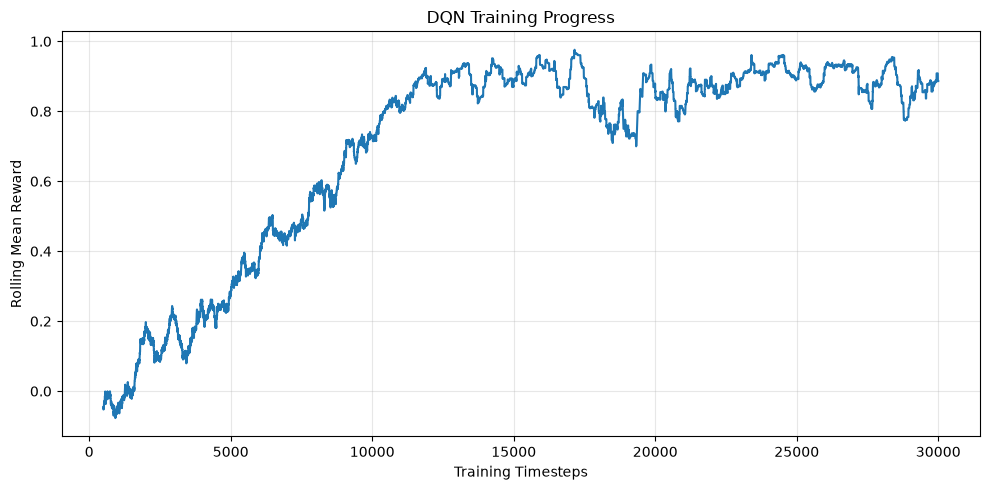

In [27]:
# ============================================================
# Q-LEARNING TRAINING PROGRESS
# ============================================================

rewards = np.array(progress_callback.rewards)
timesteps = np.array(progress_callback.timesteps)

# Rolling mean to make the learning trend easier to see
window = 500

if len(rewards) >= window:

    rolling_rewards = np.convolve(
        rewards,
        np.ones(window) / window,
        mode="valid"
    )

    rolling_timesteps = timesteps[window - 1:]

else:

    rolling_rewards = rewards
    rolling_timesteps = timesteps


plt.figure(figsize=(10, 5))

plt.plot(
    rolling_timesteps,
    rolling_rewards
)

plt.xlabel("Training Timesteps")
plt.ylabel("Rolling Mean Reward")
plt.title("DQN Training Progress")
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/dqn_training_progress.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [28]:
# ============================================================
# SYNTHETIC PATIENT TRAJECTORY GENERATOR
# ============================================================

STATE_COLUMNS = [
    "gcs_last_observed",
    "previous_observed_gcs",
    "heart_rate",
    "map",
    "resp_rate",
    "spo2",
    "hour"
]


def generate_synthetic_patient(
    patient_id,
    icustay_id,
    n_hours=120,
    deterioration_probability=0.35,
    rng=None
):

    if rng is None:
        rng = np.random.default_rng(42)

    rows = []

    # Decide whether this patient experiences deterioration
    deteriorates = (
        rng.random() < deterioration_probability
    )

    # Random deterioration point
    deterioration_start = None

    if deteriorates:

        deterioration_start = rng.integers(
            30,
            n_hours - 5
        )

    gcs = 15.0

    for hour in range(n_hours):

        # ----------------------------------------------------
        # Stable physiology
        # ----------------------------------------------------

        heart_rate = (
            82
            + rng.normal(0, 5)
        )

        map_value = (
            75
            + rng.normal(0, 5)
        )

        resp_rate = (
            18
            + rng.normal(0, 2)
        )

        spo2 = (
            97
            + rng.normal(0, 1)
        )

        current_gcs = gcs

        # ----------------------------------------------------
        # DETERIORATION TRAJECTORY
        # ----------------------------------------------------

        if (
            deteriorates
            and hour >= deterioration_start
        ):

            severity = (
                hour - deterioration_start + 1
            )

            current_gcs = max(
                3.0,
                15.0 - (
                    0.8 * severity
                )
            )

            heart_rate += (
                1.5 * severity
            )

            map_value -= (
                1.2 * severity
            )

            resp_rate += (
                0.8 * severity
            )

            spo2 -= (
                0.6 * severity
            )

        current_gcs = float(
            np.clip(
                current_gcs,
                3,
                15
            )
        )

        heart_rate = float(
            np.clip(
                heart_rate,
                45,
                180
            )
        )

        map_value = float(
            np.clip(
                map_value,
                40,
                110
            )
        )

        resp_rate = float(
            np.clip(
                resp_rate,
                8,
                45
            )
        )

        spo2 = float(
            np.clip(
                spo2,
                75,
                100
            )
        )

        # ----------------------------------------------------
        # FUTURE SAE LABEL
        # ----------------------------------------------------

        if (
            deteriorates
            and hour + 1 == deterioration_start
        ):
            future_sae = 1
        else:
            future_sae = 0

        rows.append({
            "subject_id": patient_id,
            "hadm_id": patient_id * 10,
            "icustay_id": icustay_id,
            "hour": hour,

            "gcs_last_observed": current_gcs,

            "previous_observed_gcs": gcs,

            "heart_rate": heart_rate,

            "map": map_value,

            "resp_rate": resp_rate,

            "spo2": spo2,

            "future_sae_1h": future_sae,

            "sae": 0
        })

        gcs = current_gcs

    return pd.DataFrame(rows)


print("Synthetic generator ready")

Synthetic generator ready


In [10]:
# ============================================================
# GENERATE SYNTHETIC TRAINING DATA
# ============================================================

rng = np.random.default_rng(42)

synthetic_patients = []

for i in range(30):

    patient_id = 90000 + i
    icustay_id = 900000 + i

    patient_df = generate_synthetic_patient(
        patient_id=patient_id,
        icustay_id=icustay_id,
        n_hours=120,
        deterioration_probability=0.5,
        rng=rng
    )

    synthetic_patients.append(
        patient_df
    )


synthetic_df = pd.concat(
    synthetic_patients,
    ignore_index=True
)

print("Synthetic dataset:", synthetic_df.shape)

print(
    "Synthetic patients:",
    synthetic_df["subject_id"].nunique()
)

print(
    "Synthetic ICU stays:",
    synthetic_df["icustay_id"].nunique()
)

print(
    "Synthetic future SAE:",
    synthetic_df["future_sae_1h"].sum()
)

Synthetic dataset: (3600, 12)
Synthetic patients: 30
Synthetic ICU stays: 30
Synthetic future SAE: 11


In [11]:
# ============================================================
# SAVE SYNTHETIC DATA
# ============================================================

SYNTHETIC_DIR = (
    PROJECT_ROOT /
    "data/processed/mimic3/synthetic"
)

SYNTHETIC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SYNTHETIC_PATH = (
    SYNTHETIC_DIR /
    "synthetic_sae_trajectories.csv"
)

synthetic_df.to_csv(
    SYNTHETIC_PATH,
    index=False
)

print("Synthetic dataset saved:")
print(SYNTHETIC_PATH)

Synthetic dataset saved:
/Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/data/processed/mimic3/synthetic/synthetic_sae_trajectories.csv


In [12]:
# ============================================================
# AUGMENT REAL TRAINING DATA
# ============================================================

augmented_train_df = pd.concat(
    [
        train_df,
        synthetic_df
    ],
    ignore_index=True
)

print("Original real training data:")
print(train_df.shape)

print("\nSynthetic training data:")
print(synthetic_df.shape)

print("\nAugmented training data:")
print(augmented_train_df.shape)

print(
    "\nReal training SAE:",
    train_df["future_sae_1h"].sum()
)

print(
    "Synthetic SAE:",
    synthetic_df["future_sae_1h"].sum()
)

print(
    "Total augmented SAE:",
    augmented_train_df["future_sae_1h"].sum()
)

Original real training data:
(3302, 13)

Synthetic training data:
(3600, 12)

Augmented training data:
(6902, 13)

Real training SAE: 22
Synthetic SAE: 11
Total augmented SAE: 33


In [13]:
# ============================================================
# AUGMENTED + REWARD-SHAPED DQN
# ============================================================

augmented_env = RewardShapedSAEWarningEnv(
    augmented_train_df
)

augmented_model = DQN(
    policy="MlpPolicy",
    env=augmented_env,

    learning_rate=5e-4,

    buffer_size=10000,

    learning_starts=200,

    batch_size=32,

    gamma=0.95,

    train_freq=4,

    target_update_interval=1000,

    exploration_fraction=0.4,

    exploration_final_eps=0.05,

    verbose=1,

    seed=42
)

print("Augmented DQN created")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Augmented DQN created


In [14]:
# ============================================================
# TRAIN AUGMENTED MODEL
# ============================================================

augmented_model.learn(
    total_timesteps=30000,
    progress_bar=True
)

print("Augmented DQN training complete")

Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 94.2     |
|    ep_rew_mean      | -8.38    |
|    exploration_rate | 0.97     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1811     |
|    time_elapsed     | 0        |
|    total_timesteps  | 377      |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.624    |
|    n_updates        | 44       |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 94.2     |
|    ep_rew_mean      | -8.69    |
|    exploration_rate | 0.94     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1754     |
|    time_elapsed     | 0        |
|    total_timesteps  | 754      |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.061    |
|    n_updates        | 138      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93.8     |
|    ep_rew_mean      | -6.02    |
|    exploration_rate | 0.911    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 1569     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1125     |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0297   |
|    n_updates        | 231      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -4.48    |
|    exploration_rate | 0.873    |
| time/               |          |
|    episodes         | 16       |
|    fps              | 1504     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1605     |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.364    |
|    n_updates        | 351      |
----------------------------------


...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 92.2     |
|    ep_rew_mean      | 82.8     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 292      |
|    fps              | 1332     |
|    time_elapsed     | 21       |
|    total_timesteps  | 28542    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.568    |
|    n_updates        | 7085     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 90.8     |
|    ep_rew_mean      | 81.5     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 296      |
|    fps              | 1333     |
|    time_elapsed     | 21       |
|    total_timesteps  | 28863    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0572   |
|    n_updates        | 7165     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.6     |
|    ep_rew_mean      | 81.9     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 300      |
|    fps              | 1331     |
|    time_elapsed     | 21       |
|    total_timesteps  | 29243    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0223   |
|    n_updates        | 7260     |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93.3     |
|    ep_rew_mean      | 83.3     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 304      |
|    fps              | 1332     |
|    time_elapsed     | 22       |
|    total_timesteps  | 29751    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.0662   |
|    n_updates        | 7387     |
----------------------------------


Augmented DQN training complete


In [15]:
# ============================================================
# EVALUATE AUGMENTED MODEL
# ============================================================

augmented_results = evaluate_model(
    augmented_model,
    test_df
)

print("AUGMENTED DQN")
print("============================")

print(
    "Precision:",
    augmented_results["precision"]
)

print(
    "Recall:",
    augmented_results["recall"]
)

print(
    "F1:",
    augmented_results["f1"]
)

print(
    "Total reward:",
    augmented_results["total_reward"]
)

print("\nConfusion matrix:")
print(
    augmented_results["confusion_matrix"]
)

AUGMENTED DQN
Precision: 0.0
Recall: 0.0
F1: 0.0
Total reward: 1174.5

Confusion matrix:
[[1240    1]
 [  13    0]]


In [16]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Original DQN",
        "Reward-Shaped DQN",
        "Synthetic-Augmented DQN"
    ],

    "Precision": [
        0.058823529411764705,
        reward_results["precision"],
        augmented_results["precision"]
    ],

    "Recall": [
        0.3333333333333333,
        reward_results["recall"],
        augmented_results["recall"]
    ],

    "F1": [
        0.10,
        reward_results["f1"],
        augmented_results["f1"]
    ],

    "Total Reward": [
        82.0,
        reward_results["total_reward"],
        augmented_results["total_reward"]
    ]
})

display(comparison)

,Model,Precision,Recall,F1,Total Reward
0,Original DQN,0.058824,0.333333,0.1,82.0
1,Reward-Shaped DQN,0.000000,0.000000,0.0,1176.0
2,Synthetic-Augmented DQN,0.000000,0.000000,0.0,1174.5


In [17]:
# ============================================================
# SAVE FINAL RESULTS
# ============================================================

RESULTS_PATH = (
    PROJECT_ROOT /
    "data/processed/mimic3" /
    "sae_rl_improvement_results.csv"
)

comparison.to_csv(
    RESULTS_PATH,
    index=False
)

# Save models
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

reward_model.save(
    str(
        MODELS_DIR /
        "dqn_sae_reward_shaped"
    )
)

augmented_model.save(
    str(
        MODELS_DIR /
        "dqn_sae_synthetic_augmented"
    )
)

print("========================================")
print("EXPERIMENTS COMPLETE")
print("========================================")

print("\nResults:")
print(RESULTS_PATH)

print("\nModels:")
print(
    MODELS_DIR /
    "dqn_sae_reward_shaped"
)

print(
    MODELS_DIR /
    "dqn_sae_synthetic_augmented"
)

EXPERIMENTS COMPLETE

Results:
/Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/data/processed/mimic3/sae_rl_improvement_results.csv

Models:
/Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/models/dqn_sae_reward_shaped
/Users/chinmay/Clg Stuff/Research Stuff/SAE_RL_EarlyWarning/models/dqn_sae_synthetic_augmented
